RunnableSequence() func refered to |   -> called as LCEL(langchain expressive langchain)

## RunnableSequence.py and simplechain

2 prompts are used, with 2nd having requiring diff input

BTW Even in 'outparser proj', we had an example with model being used twice 

During second time if the input required from first model in chain is "not enough" + "var name is diff", use below method

chain = (
    prompt1\
    | model\
    | parser\
    | (lambda x: {"text": x, "chat_history": hist})\
    | prompt2\
    | model\
    | parser
)

***

## parallel chain

used runnableParallel in this

<pre>
RunnableParallel(
    ('key1'- O/P1),
    ('key2'- O/P2)
)
</pre>

***

## conditional chain

- Here we used pydantic because , instead of single pos or neg output, i was gettin o/p as sentence 

But if pydantic parser fails then, 'try catch' is used



- RunnablBranch(i) & RunnableLambda(ii) is used

i -to make sure the code runs in connected manner without 'if else' 

ii - and RunnableLambda is used incase

In [ ]:
RunnableBranch(
    (condition1 -(if true runs func1 else goes to cond2), func1),
    (condition2, fun2),
    (do whatever here- (eg. print 'Failure') )
)

*usually RunnablePassthrough is used in case of default*

branch_chain = RunnableBranch(
    (lambda x: len(x.split())>300, prompt2 | model | parser),
    RunnablePassthrough()
)

RunnableLambda is like

def my_step(x):
    return x.upper()
my_step(o/p of previous runable)

***

## RunnablePassthrough

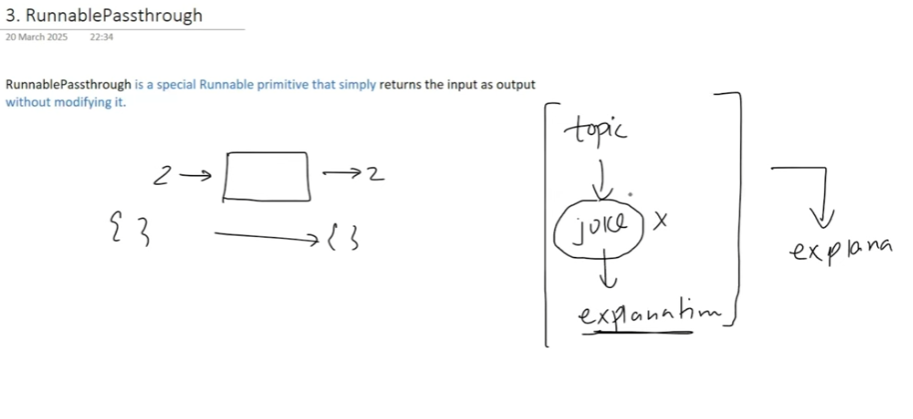


Like along with that explanation i want that joke to be printed (uses RunnableParallel)

***

## RunnableLambda

like god of everything- useful where normally cant put it in chain

RunnableLambda is a runnable primitive that allows you to apply **custom Python functions**
within an Al pipeline.

It acts as a middleware between different Al components, enabling preprocessing,
transformation, API calls, filtering, and post-processing in a LangChain workflow.


EG. LLm is not good at find no. of words ,

<pre>:
prompt ->llm->parser->RunParallel -> count(func)\
                                    -> joke(llm)

<code>:
clsR = RunnableLambda(len('HI how are u Bud?'.split()))
</code>
- This Above is not possible since RLambda requires *func as param*, not dict or int,etc 
- also dont call the func inside just pass it, since calling it will return some value 
                                  

In [8]:
from langchain_core.runnables import RunnableSequence, RunnableLambda, RunnablePassthrough, RunnableParallel


fL = lambda tex: len(tex.split())

clsR = RunnableLambda(fL)
clsR.invoke("HI how are u bud?")


5

# Extra
 
*understanding of lambda*

func = lambda x: 12  <br>
print(func(5))   # Output: 12  <br>
print(func(100)) # Output: 12 <br>


SO if o/p will be not in cond, it will be the provided text

*understanding of lambda 2*
```bash
RunnableLambda(lambda state: (
        lambda response: {
            **state,
            "ai_message": response,
            "messages": state["messages"] + [response]
        }
    )(llm_with_tools.invoke(state["messages"])))

```

# ----- Runnables

In [ ]:
Some models require special formatting.

For example, BGE embedding model works better if you prefix queries:

"query: your question"
"passage: your document"

This improves embedding alignment.

***

### old_pdf_reader.py

##### *why retrieved_text = "\n".join([doc.page_content for doc in retrieved_docs]) is used *

<br> <br> When you use:

retrieved_docs = retriever.get_relevant_documents(query)

The retriever returns:

List[Document]

...
class Document:
    page_content: str
    metadata: dict
doc.page_content

...

retriever.get_relevant_documents() already returns Document objects.

You don’t need to import the class to use its attributes.

You’re just accessing properties of returned objects.

Mental model
retrieved_docs = [Document(), Document(), Document()]

Each has:

doc.page_content
doc.metadata

That’s it.
<br> <br> <br> <br>

***

**old_RetrievalQAchain.py and old_llmchain** 

these are just 2 type of chain func, which were built to connect different things like (llm & prompt) or (llm + docs +__)

 there are many other chains that are built

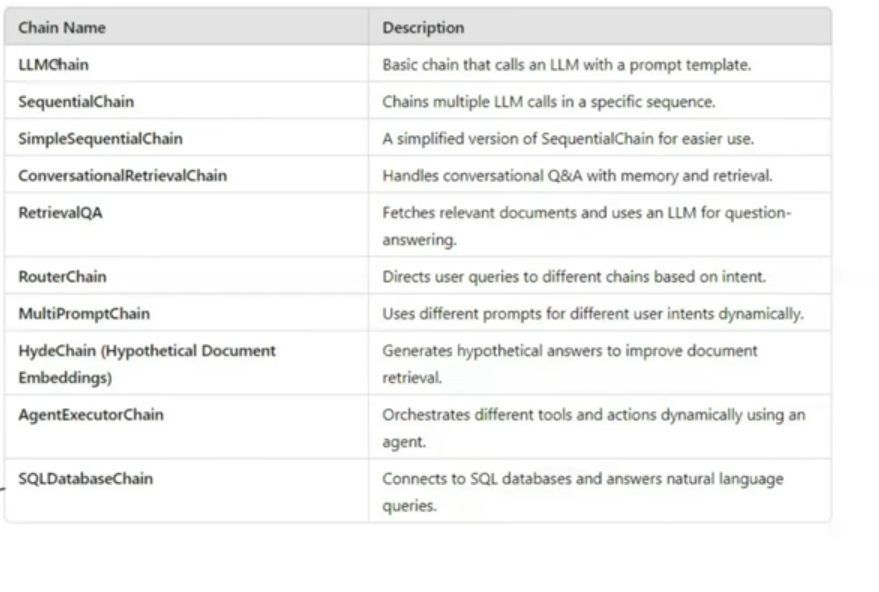

**Runnable working egs**

aam_zind_problem.ipynb - it showcases the problem which was prev there  https://colab.research.google.com/drive/1gv3e-OfHCi6IuVBVR7xWmrcVl6gHsydv?usp=sharing#scrollTo=SGzmKwmDDOfe

aam_solution.ipynb   - it showcases the soln the langchain team found 

https://colab.research.google.com/drive/1P11hpAPtjr0oIiqQ5pNsdnMxmascdbBY?usp=sharing

## WHAT IS RUNNABLE

ITS anything which takes input -> prcocesses -> output

- Two types-  i)Task specific ii) RUnnable Primitive

i) include - ChatOpenAI, Prompttemplate, StrOutParser, Retriever, etc as given above

ii) RunnableParrallel, RunnableSequence, 